In [8]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

print("libraries loaded!")

libraries loaded!


In [2]:
df_tickets = pd.read_csv("../data/incident_tickets.csv")
df_logs    = pd.read_csv("../data/system_logs.csv")

print("Tickets shape:", df_tickets.shape)
print("Logs shape:", df_logs.shape)

Tickets shape: (25000, 9)
Logs shape: (25000, 6)


In [3]:
# Check first 5 rows of tickets
print("=== Tickets Sample ===")
print(df_tickets.head())

print("\n=== Logs Sample ===")
print(df_logs.head())

=== Tickets Sample ===
  ticket_id created_date  category priority assigned_team     status  \
0     TKT-1   2026-01-23   Network       P1        Team C   Resolved   
1     TKT-2   2026-01-16   Network       P4        Team A   Resolved   
2     TKT-3   2026-03-20   Network       P2        Team D   Resolved   
3     TKT-4   2026-02-02  Hardware       P4        Team C  Escalated   
4     TKT-5   2025-12-17   Network       P4        Team A  Escalated   

   resolution_time_hrs  is_escalated server_id  
0                16.85             0  Server-E  
1                 7.65             0  Server-E  
2                32.89             0  Server-A  
3                12.04             0  Server-A  
4                61.17             0  Server-A  

=== Logs Sample ===
  log_id            timestamp server_id log_level  uptime_percentage  \
0  LOG-1  2025-12-21 03:13:19  Server-E      WARN              99.55   
1  LOG-2  2025-08-31 00:56:51  Server-D      INFO              92.69   
2  LOG-3  202

In [4]:
print("=== Tickets Info ===")
print(df_tickets.info())

print("\n=== Null Values in Tickets ===")
print(df_tickets.isnull().sum())

print("\n=== Null Values in Logs ===")
print(df_logs.isnull().sum())

=== Tickets Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ticket_id            25000 non-null  object 
 1   created_date         25000 non-null  object 
 2   category             25000 non-null  object 
 3   priority             25000 non-null  object 
 4   assigned_team        25000 non-null  object 
 5   status               25000 non-null  object 
 6   resolution_time_hrs  25000 non-null  float64
 7   is_escalated         25000 non-null  int64  
 8   server_id            25000 non-null  object 
dtypes: float64(1), int64(1), object(7)
memory usage: 1.7+ MB
None

=== Null Values in Tickets ===
ticket_id              0
created_date           0
category               0
priority               0
assigned_team          0
status                 0
resolution_time_hrs    0
is_escalated           0
server_id             

In [5]:
#Clean Data
# Drop nulls
df_tickets = df_tickets.dropna()
df_logs    = df_logs.dropna()

# Fix date column
df_tickets["created_date"] = pd.to_datetime(df_tickets["created_date"])

# Fix timestamp column
df_logs["timestamp"] = pd.to_datetime(df_logs["timestamp"])

# Extract month from date
df_tickets["month"] = df_tickets["created_date"].dt.to_period("M").astype(str)

# Extract hour from timestamp
df_logs["hour"] = df_logs["timestamp"].dt.hour

print("Data cleaned ✓")
print("Tickets shape after cleaning:", df_tickets.shape)
print("Logs shape after cleaning:", df_logs.shape)


Data cleaned ✓
Tickets shape after cleaning: (25000, 10)
Logs shape after cleaning: (25000, 7)


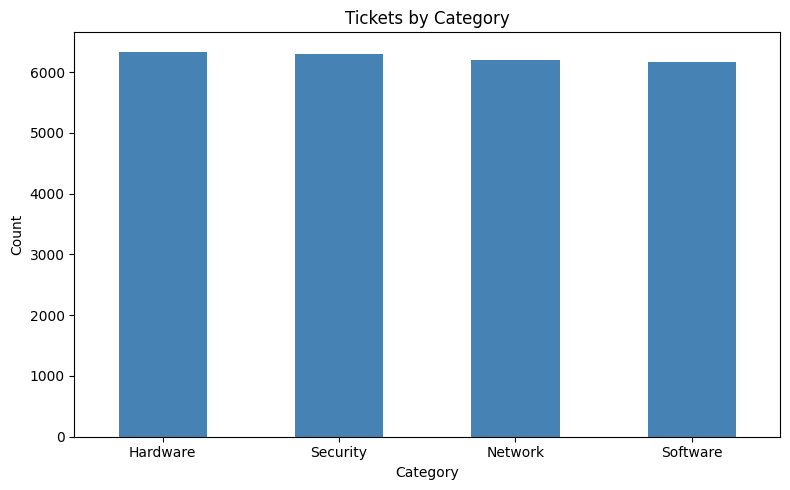

Chart 1 saved ✓


In [9]:
#Chart 1 tic by category
plt.figure(figsize=(8, 5))
df_tickets["category"].value_counts().plot(kind="bar", color="steelblue")
plt.title("Tickets by Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../data/chart1_category.png")
plt.show()
print("Chart 1 saved ✓")

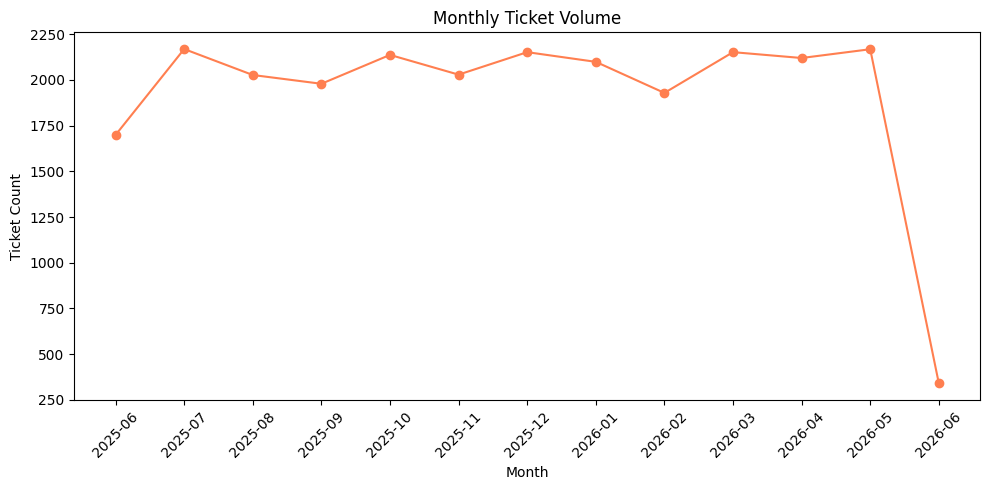

Chart 2 saved ✓


In [10]:
#Chart 2 monthly ticket trend
monthly = df_tickets.groupby("month")["ticket_id"].count().reset_index()
monthly.columns = ["month", "count"]

plt.figure(figsize=(10, 5))
plt.plot(monthly["month"], monthly["count"], marker="o", color="coral")
plt.title("Monthly Ticket Volume")
plt.xlabel("Month")
plt.ylabel("Ticket Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../data/chart2_monthly.png")
plt.show()
print("Chart 2 saved ✓")

C:\Users\Deval Pathak\AppData\Local\Temp\ipykernel_12692\2907667369.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_tickets, x="priority", y="resolution_time_hrs", palette="Set2")


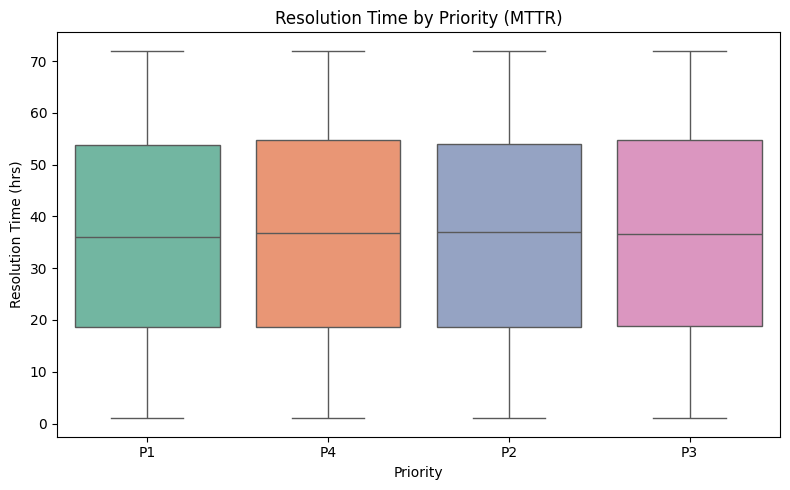

Chart 3 saved ✓


In [11]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_tickets, x="priority", y="resolution_time_hrs", palette="Set2")
plt.title("Resolution Time by Priority (MTTR)")
plt.xlabel("Priority")
plt.ylabel("Resolution Time (hrs)")
plt.tight_layout()
plt.savefig("../data/chart3_mttr.png")
plt.show()
print("Chart 3 saved ✓")

C:\Users\Deval Pathak\AppData\Local\Temp\ipykernel_12692\3515719721.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=escalation, x="assigned_team", y="escalation_pct", palette="Set1")


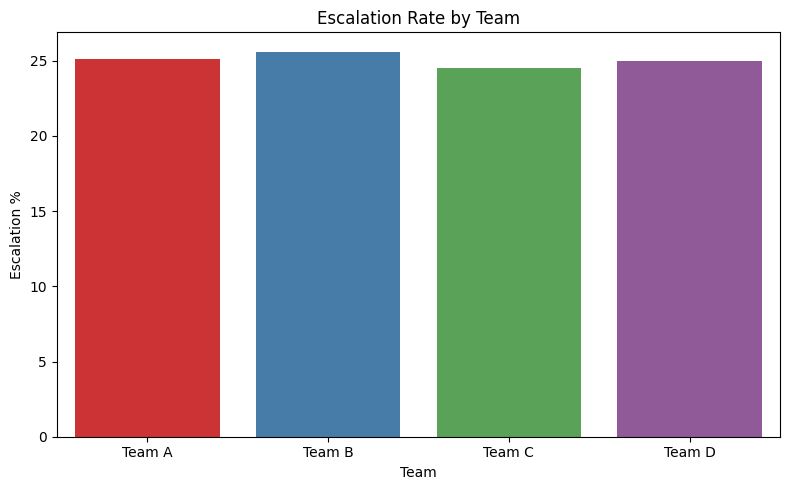

Chart 4 saved ✓


In [12]:
escalation = df_tickets.groupby("assigned_team").agg(
    total=("ticket_id", "count"),
    escalated=("is_escalated", "sum")
).reset_index()

escalation["escalation_pct"] = round(
    100 * escalation["escalated"] / escalation["total"], 1
)

plt.figure(figsize=(8, 5))
sns.barplot(data=escalation, x="assigned_team", y="escalation_pct", palette="Set1")
plt.title("Escalation Rate by Team")
plt.xlabel("Team")
plt.ylabel("Escalation %")
plt.tight_layout()
plt.savefig("../data/chart4_escalation.png")
plt.show()
print("Chart 4 saved ✓")

In [13]:
# This is your "30% time saving" proof
summary = df_tickets.groupby("category").agg(
    total_tickets=("ticket_id", "count"),
    avg_resolution_hrs=("resolution_time_hrs", "mean"),
    escalation_count=("is_escalated", "sum")
).round(2).reset_index()

summary.to_excel("../data/kpi_report.xlsx", index=False)
print("KPI Report saved to Excel ✓")
print(summary)

KPI Report saved to Excel ✓
   category  total_tickets  avg_resolution_hrs  escalation_count
0  Hardware           6339               36.18              1633
1   Network           6205               36.93              1519
2  Security           6292               36.27              1566
3  Software           6164               36.74              1548
